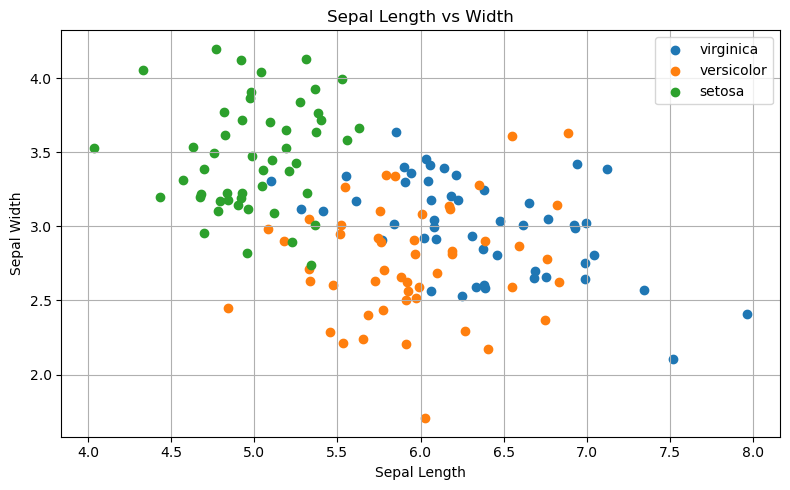

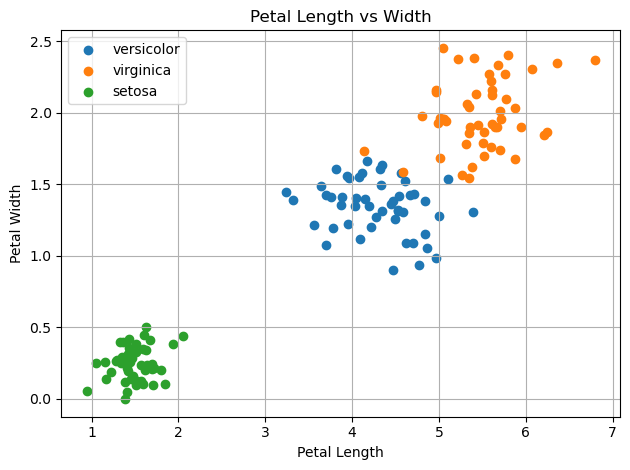

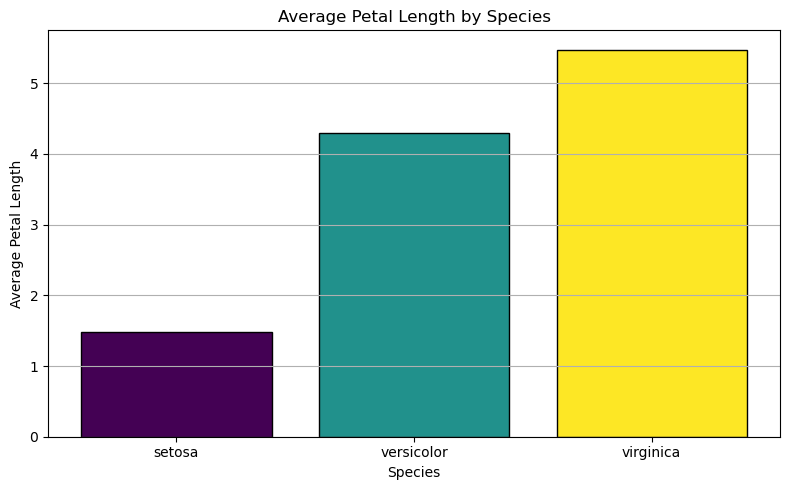

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Loading data two Iris dataset files into Pandas DataFrames
#The sepal file contains measurements related to sepals,
#the petal file contains measurements related to petals.

sepal = pd.read_csv("Sepal_Data.csv")
petal = pd.read_csv("Petal_Data.csv")



#Visualization 1:Sepal Scatter

#This scatter plot is used to compare the relationship between sepal length and sepal width for each flower species.
#The Scatter plots are useful here because both variables are numeric, and we want to see whether the species form distinct clusters.
plt.figure(figsize=(8,5))

#Loop through each of unique species so that each species can be plotted separately with its own label.
for species in sepal['species'].unique():
    subset = sepal[sepal['species'] == species]
    #Plotting sepal length on the x-axis and sepal width on the y-axis.
    plt.scatter(subset['sepal_length'], subset['sepal_width'], label=species)

#Adding a descriptive title and axis labels so the reader knows exactly what the graph represents.
plt.title("Sepal Length vs Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()   #Showing a legend so the viewer can identify which points belong to each species.
plt.grid(True)  #Adding grid lines to make the plot easier to read.
plt.tight_layout() #Tight layout helps prevent labels from being cut off.
plt.show()



#Visualization 2:Petal Scatter 

#This scatter plot compares petal length and petal width. These measurements are often more effective than sepal measurements
#for distinguishing between Iris species, so this graph helps us visually check how clearly the species separate.
plt.figure()

#loop through each species and plot each group separately.
for species in petal['species'].unique():
    subset = petal[petal['species'] == species]
    plt.scatter(subset['petal_length'], subset['petal_width'], label=species)

plt.title("Petal Length vs Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Visualization 3: Average Petal Length by Species

#A bar chart is used here to compare the average petal length across the different flower species.
#This provides a simple summary view and makes it easy to compare overall differences between groups.

#Grouping the petal data by species and calculate the mean petal length.
avg_petal_length = petal.groupby("species")["petal_length"].mean().sort_values()

#Creating a gradient color scheme so the bars follow the sorted order.
colors = plt.cm.viridis(np.linspace(0, 1, len(avg_petal_length)))

plt.figure(figsize=(8,5))
plt.bar(avg_petal_length.index, avg_petal_length.values, color=colors, edgecolor="black")

plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Average Petal Length")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

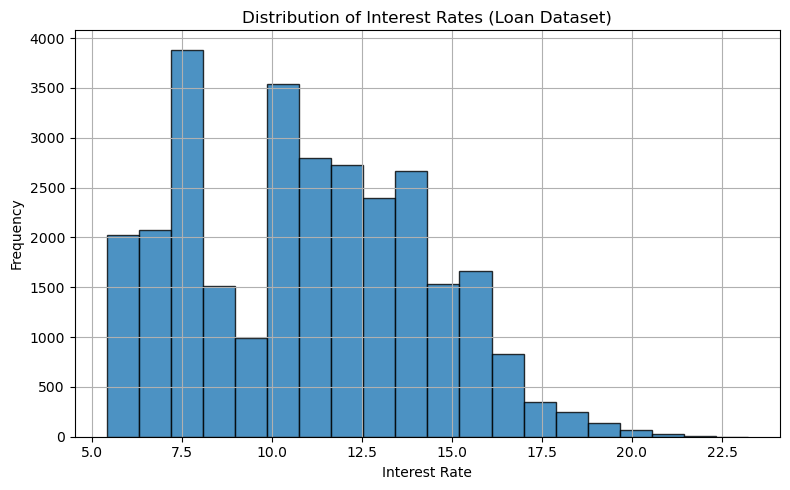

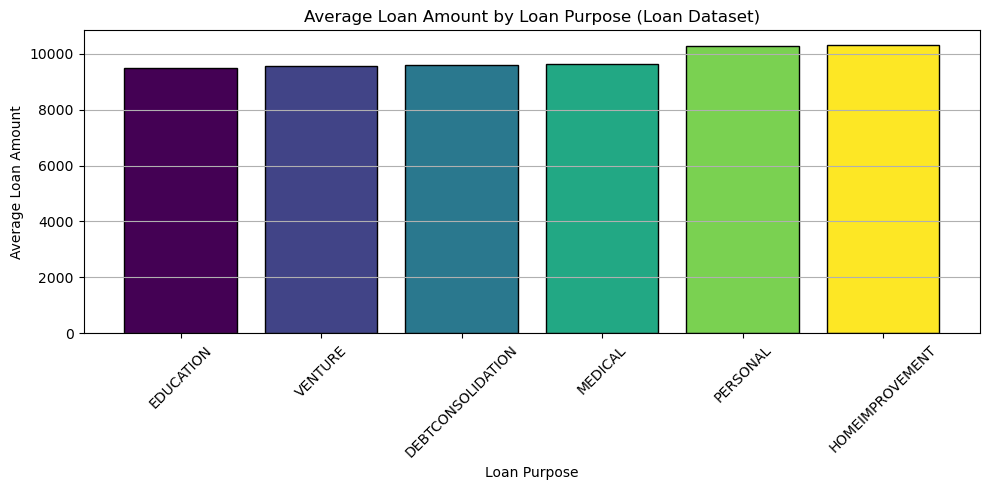

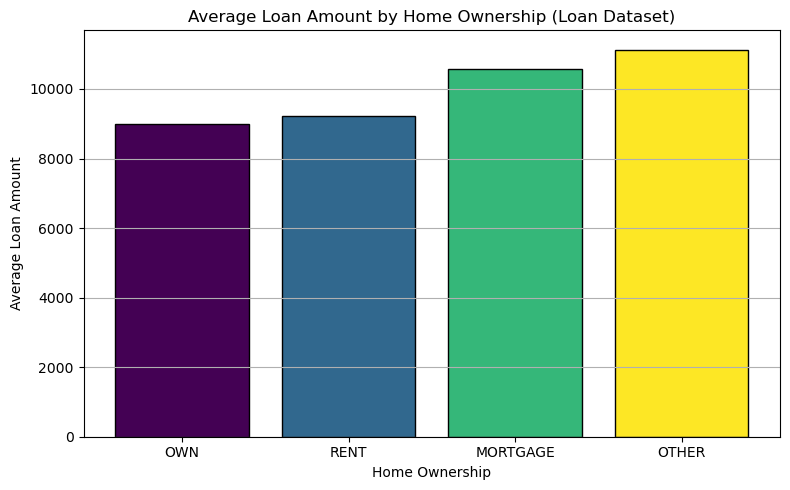

In [98]:
#Loading the loan dataset from the CSV file into a pandas DataFrame.
#This dataset has both categorical and numeric loan-related features.
loan_df = pd.read_csv("LoanDataset - LoansDatasest.csv")


# Data Cleaning
#The loan amount column contains currency symbols and commas, thus those characters must be removed before converting the values
#into numeric format. This is necessary because matplotlib cannot properly graph text-formatted numbers.

loan_df["loan_amnt"] = loan_df["loan_amnt"].replace(r"[£,]", "", regex=True)
loan_df["loan_amnt"] = pd.to_numeric(loan_df["loan_amnt"], errors="coerce")

#Converting the interest rate column to numeric values as well.
#Any invalid values are going to turned into NaN using errors="coerce".
loan_df["loan_int_rate"] = pd.to_numeric(loan_df["loan_int_rate"], errors="coerce")

#Removing rows with missing values in the columns needed for plotting.
#I think this prevents graphing errors and ensures the visualizations are based on valid, usable data only.
loan_df = loan_df.dropna(subset=["loan_amnt", "loan_int_rate", "loan_intent", "home_ownership"])


# Visualization 1:Distribution of Interest Rates

# A histogram is the best choice here because interest rate is a numeric variable and we want to examine its distribution.
#This plot helps us see where most loans are concentrated and whether high-interest loans are rare or common.

plt.figure(figsize=(8,5))

plt.hist(loan_df["loan_int_rate"], bins=20, edgecolor="black", alpha=0.8)

plt.title("Distribution of Interest Rates (Loan Dataset)")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")

#The grid lines improve readability of the frequency scale.
plt.grid(True)
plt.tight_layout()
plt.show()



# Visualization 2: Average Loan Amount by Loan Purpose

#Here, a bar chart is used because loan purpose is a categorical variable and loan amount is numeric. This lets us compare the average amount
#borrowed across different loan purposes.
#sorting the averages makes the ranking easier to understand visually.

avg_by_intent = loan_df.groupby("loan_intent")["loan_amnt"].mean().sort_values()

#creating a color gradient so the bar colors visually follow the sorted order.
colors1 = plt.cm.viridis(np.linspace(0, 1, len(avg_by_intent)))

plt.figure(figsize=(10,5))
plt.bar(avg_by_intent.index, avg_by_intent.values, color=colors1, edgecolor="black")

plt.title("Average Loan Amount by Loan Purpose (Loan Dataset)")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Loan Amount")

#rotating category labels so they do not overlap.
plt.xticks(rotation=45)

#adding horizontal grid lines to make value comparison easier.
plt.grid(axis="y")
plt.tight_layout()
plt.show()



# Visualization 3: Average Loan Amount by Home Ownership

#This bar chart compares the average loan amount across different home ownership categories.
# Since home ownership is categorical, a bar chart is a good way to compare the numeric averages between groups.

home_group = loan_df.groupby("home_ownership")["loan_amnt"].mean().sort_values()

#using a second gradient color sequence so colors follow the sorted order here too.
colors2 = plt.cm.viridis(np.linspace(0, 1, len(home_group)))

plt.figure(figsize=(8,5))
plt.bar(home_group.index, home_group.values, color=colors2, edgecolor="black")

plt.title("Average Loan Amount by Home Ownership (Loan Dataset)")
plt.xlabel("Home Ownership")
plt.ylabel("Average Loan Amount")

#the horizontal grid lines help make the bar heights easier to compare.
plt.grid(axis="y")
plt.tight_layout()
plt.show()